<a href="https://colab.research.google.com/github/oguzhanguler1/titanic_competition/blob/main/submission4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [220]:
import pandas as pd
import numpy as np

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape)
print(test.shape)

train.head()

(891, 12)
(418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [221]:
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [222]:
train.groupby("Survived")["Fare"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
Survived,,,,,
0,549,22.117887,10.5,0.0,263.0000
1,342,48.395408,26.0,0.0,512.3292


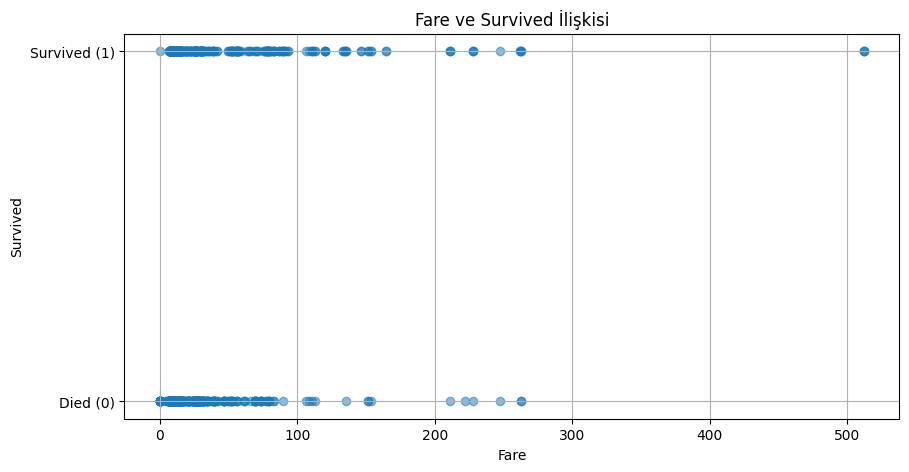

In [223]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(train["Fare"], train["Survived"], alpha=0.5)

plt.xlabel("Fare")
plt.ylabel("Survived")
plt.title("Fare ve Survived İlişkisi")

plt.yticks([0, 1], ["Died (0)", "Survived (1)"])
plt.grid(True)

plt.show()

/tmp/ipykernel_2082/452172958.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


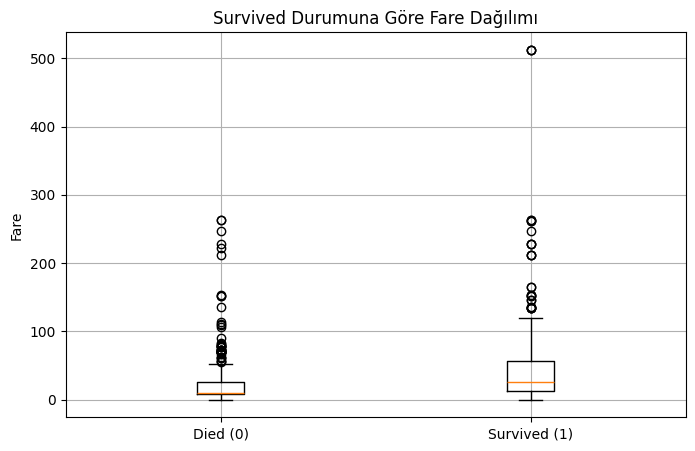

In [224]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        train[train["Survived"] == 0]["Fare"],
        train[train["Survived"] == 1]["Fare"]
    ],
    labels=["Died (0)", "Survived (1)"]
)

plt.ylabel("Fare")
plt.title("Survived Durumuna Göre Fare Dağılımı")
plt.grid(True)

plt.show()

/tmp/ipykernel_2082/3297171076.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


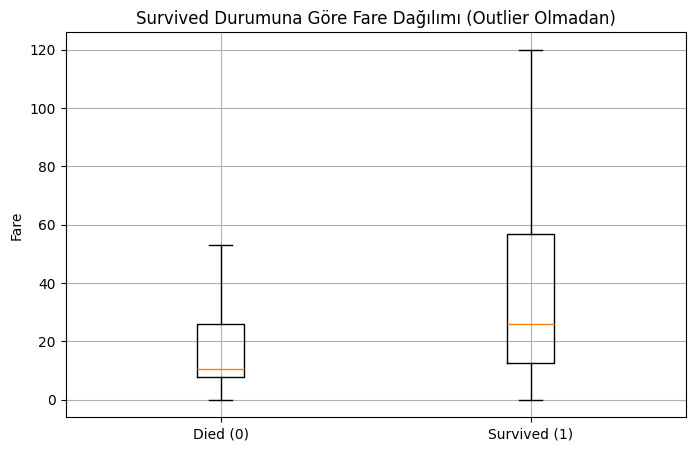

In [225]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        train[train["Survived"] == 0]["Fare"],
        train[train["Survived"] == 1]["Fare"]
    ],
    labels=["Died (0)", "Survived (1)"],
    showfliers=False
)

plt.ylabel("Fare")
plt.title("Survived Durumuna Göre Fare Dağılımı (Outlier Olmadan)")
plt.grid(True)

plt.show()

/tmp/ipykernel_2082/3248393569.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


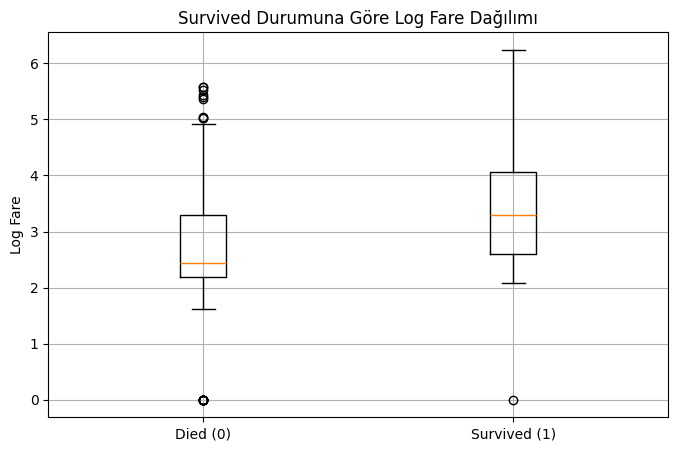

In [226]:
train["Fare_log"] = np.log1p(train["Fare"])

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        train[train["Survived"] == 0]["Fare_log"],
        train[train["Survived"] == 1]["Fare_log"]
    ],
    labels=["Died (0)", "Survived (1)"]
)

plt.ylabel("Log Fare")
plt.title("Survived Durumuna Göre Log Fare Dağılımı")
plt.grid(True)

plt.show()

In [227]:
female_train = train[train["Sex"] == "female"].copy()

In [228]:
female_train.groupby("Survived")["Fare"].agg(
    Count="count",
    MeanFare="mean",
    MedianFare="median",
    MinFare="min",
    MaxFare="max"
)

,Count,MeanFare,MedianFare,MinFare,MaxFare
Survived,,,,,
0,81,23.024385,15.2458,6.750,151.5500
1,233,51.938573,26.0000,7.225,512.3292


In [229]:
female_train.groupby(["Pclass", "Survived"])["Fare"].agg(
    Count="count",
    MeanFare="mean",
    MedianFare="median",
    MinFare="min",
    MaxFare="max"
)

Count    MeanFare  MedianFare  MinFare   MaxFare
Pclass Survived                                                  
1      0             3  110.604167   151.55000  28.7125  151.5500
       1            91  105.978159    82.17080  25.9292  512.3292
2      0             6   18.250000    17.00000  10.5000   26.0000
       1            70   22.288989    23.00000  10.5000   65.0000
3      0            72   19.773093    14.47915   6.7500   69.5500
       1            72   12.464526     9.46875   7.2250   31.3875

/tmp/ipykernel_2082/3574354592.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


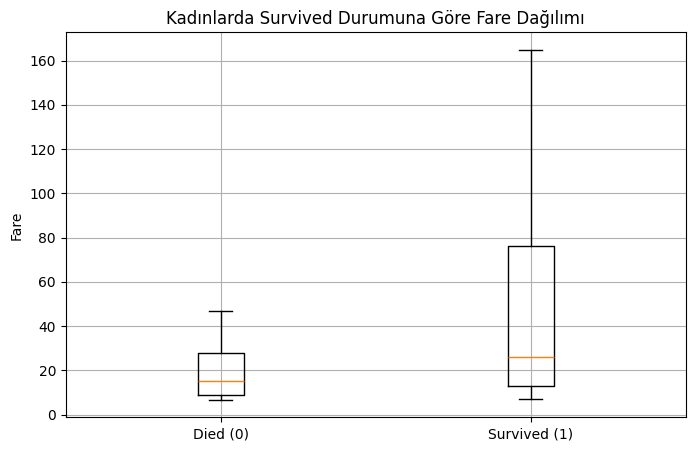

In [230]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        female_train[female_train["Survived"] == 0]["Fare"],
        female_train[female_train["Survived"] == 1]["Fare"]
    ],
    labels=["Died (0)", "Survived (1)"],
    showfliers=False
)

plt.ylabel("Fare")
plt.title("Kadınlarda Survived Durumuna Göre Fare Dağılımı")
plt.grid(True)

plt.show()

/tmp/ipykernel_2082/1701649571.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


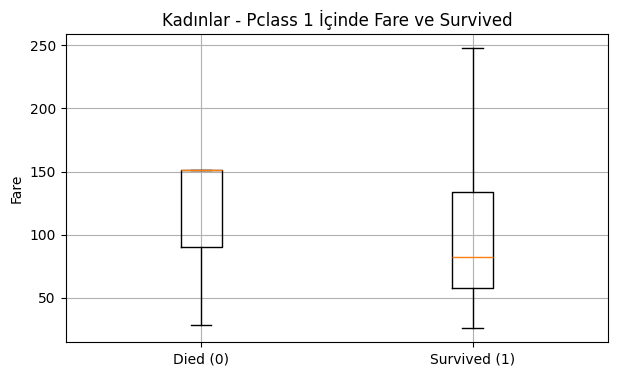

/tmp/ipykernel_2082/1701649571.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


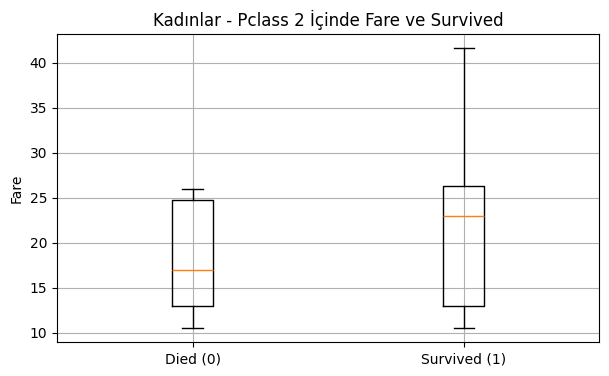

/tmp/ipykernel_2082/1701649571.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


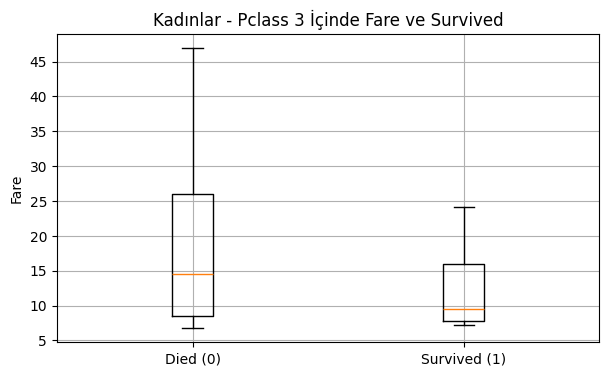

In [231]:
for pclass in sorted(female_train["Pclass"].unique()):
    data = female_train[female_train["Pclass"] == pclass]

    plt.figure(figsize=(7, 4))

    plt.boxplot(
        [
            data[data["Survived"] == 0]["Fare"],
            data[data["Survived"] == 1]["Fare"]
        ],
        labels=["Died (0)", "Survived (1)"],
        showfliers=False
    )

    plt.ylabel("Fare")
    plt.title(f"Kadınlar - Pclass {pclass} İçinde Fare ve Survived")
    plt.grid(True)
    plt.show()

In [232]:
train_check = train.drop(columns=["Survived"]).copy()
test_check = test.copy()

all_data = pd.concat([train_check, test_check], ignore_index=True)

all_data["TicketCount"] = all_data.groupby("Ticket")["Ticket"].transform("count")

train = train.merge(
    all_data[["PassengerId", "TicketCount"]],
    on="PassengerId",
    how="left"
)

In [233]:
from sklearn.impute import SimpleImputer

age_imputer = SimpleImputer(strategy="median")
fare_imputer = SimpleImputer(strategy="median")

train["Age_Imputed"] = age_imputer.fit_transform(train[["Age"]])
train["Fare_Imputed"] = fare_imputer.fit_transform(train[["Fare"]])

In [234]:
# 1) Pclass 3 mü?
train["IsPclass3"] = (train["Pclass"] == 3).astype(int)

# 2) FareGroup
train["FareGroup"] = pd.cut(
    train["Fare_Imputed"],
    bins=[-1, 0, 10, 25, 50, 100, 600],
    labels=["Zero", "VeryLow", "Low", "Medium", "High", "VeryHigh"]
)

# 3) HasCabin
train["HasCabin"] = train["Cabin"].notnull().astype(int)

# 4) WomanOrChild
train["WomanOrChild"] = (
    (train["Sex"] == "female") |
    (train["Age_Imputed"] <= 12)
).astype(int)

# 5) IsAlone_WithTicket
train["IsAlone_WithTicket"] = (
    (train["SibSp"] == 0) &
    (train["Parch"] == 0) &
    (train["TicketCount"] == 1)
).astype(int)

# 6) SibSpHighRisk
train["SibSpHighRisk"] = (train["SibSp"] >= 3).astype(int)

# 7) ParchHighRisk
train["ParchHighRisk"] = (train["Parch"] >= 4).astype(int)

In [235]:
features = [
    "IsPclass3",
    "FareGroup",
    "HasCabin",
    "WomanOrChild",
    "IsAlone_WithTicket",
    "SibSpHighRisk",
    "ParchHighRisk"
]

train[features + ["Survived"]].head()

,IsPclass3,FareGroup,HasCabin,WomanOrChild,IsAlone_WithTicket,SibSpHighRisk,ParchHighRisk,Survived
0,1,VeryLow,0,0,0,0,0,0
1,0,High,1,1,0,0,0,1
2,1,VeryLow,0,1,1,0,0,1
3,0,High,1,1,0,0,0,1
4,1,VeryLow,0,0,1,0,0,0


In [236]:
train[features].isnull().sum()

,0
IsPclass3,0
FareGroup,0
HasCabin,0
WomanOrChild,0
IsAlone_WithTicket,0
SibSpHighRisk,0
ParchHighRisk,0


In [237]:
X = train[features]
y = train["Survived"]

In [238]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [239]:
categorical_features = ["FareGroup"]

numeric_features = [
    "IsPclass3",
    "HasCabin",
    "WomanOrChild",
    "IsAlone_WithTicket",
    "SibSpHighRisk",
    "ParchHighRisk"
]

fare_order = [["Zero", "VeryLow", "Low", "Medium", "High", "VeryHigh"]]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        categories=fare_order,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [240]:
models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("SVC", SVC()),
    ("KNN", KNeighborsClassifier()),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("Random Forest", RandomForestClassifier(random_state=42)),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=42))
]

In [241]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for model_name, model in models:
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        clf,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    results.append({
        "Model": model_name,
        "Mean Accuracy": scores.mean(),
        "Std": scores.std(),
        "Scores": scores
    })

results_df = pd.DataFrame(results).sort_values(
    by="Mean Accuracy",
    ascending=False
)

results_df[["Model", "Mean Accuracy", "Std"]]

,Model,Mean Accuracy,Std
3,Decision Tree,0.833884,0.013697
4,Random Forest,0.832760,0.011061
5,Gradient Boosting,0.826025,0.007397
1,SVC,0.826025,0.014793
0,Logistic Regression,0.824907,0.011575
2,KNN,0.822648,0.021663


In [242]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

single_results = []

for model_name, model in models:
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_valid)

    acc = accuracy_score(y_valid, y_pred)

    single_results.append({
        "Model": model_name,
        "Single Accuracy": acc
    })

single_results_df = pd.DataFrame(single_results).sort_values(
    by="Single Accuracy",
    ascending=False
)

single_results_df

,Model,Single Accuracy
1,SVC,0.821229
0,Logistic Regression,0.815642
3,Decision Tree,0.810056
4,Random Forest,0.798883
5,Gradient Boosting,0.798883
2,KNN,0.754190


In [243]:
# Test için aynı featureları oluşturalım

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# train + test birlikte TicketCount
train_check = train.drop(columns=["Survived"]).copy()
test_check = test.copy()

all_data = pd.concat([train_check, test_check], ignore_index=True)
all_data["TicketCount"] = all_data.groupby("Ticket")["Ticket"].transform("count")

# TicketCount'u train ve test'e ekle
train = train.merge(
    all_data[["PassengerId", "TicketCount"]],
    on="PassengerId",
    how="left"
)

test = test.merge(
    all_data[["PassengerId", "TicketCount"]],
    on="PassengerId",
    how="left"
)

In [244]:
from sklearn.impute import SimpleImputer

age_imputer = SimpleImputer(strategy="median")
fare_imputer = SimpleImputer(strategy="median")

train["Age_Imputed"] = age_imputer.fit_transform(train[["Age"]])
test["Age_Imputed"] = age_imputer.transform(test[["Age"]])

train["Fare_Imputed"] = fare_imputer.fit_transform(train[["Fare"]])
test["Fare_Imputed"] = fare_imputer.transform(test[["Fare"]])

In [245]:
def create_selected_features(df):
    df = df.copy()

    df["IsPclass3"] = (df["Pclass"] == 3).astype(int)

    df["FareGroup"] = pd.cut(
        df["Fare_Imputed"],
        bins=[-1, 0, 10, 25, 50, 100, 600],
        labels=["Zero", "VeryLow", "Low", "Medium", "High", "VeryHigh"]
    )

    df["HasCabin"] = df["Cabin"].notnull().astype(int)

    df["WomanOrChild"] = (
        (df["Sex"] == "female") |
        (df["Age_Imputed"] <= 12)
    ).astype(int)

    df["IsAlone_WithTicket"] = (
        (df["SibSp"] == 0) &
        (df["Parch"] == 0) &
        (df["TicketCount"] == 1)
    ).astype(int)

    df["SibSpHighRisk"] = (df["SibSp"] >= 3).astype(int)

    df["ParchHighRisk"] = (df["Parch"] >= 4).astype(int)

    return df

In [246]:
train_fe = create_selected_features(train)
test_fe = create_selected_features(test)

In [247]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [248]:
features = [
    "IsPclass3",
    "FareGroup",
    "HasCabin",
    "WomanOrChild",
    "IsAlone_WithTicket",
    "SibSpHighRisk",
    "ParchHighRisk"
]

X = train_fe[features]
y = train_fe["Survived"]
X_test = test_fe[features]

In [249]:
categorical_features = ["FareGroup"]

numeric_features = [
    "IsPclass3",
    "HasCabin",
    "WomanOrChild",
    "IsAlone_WithTicket",
    "SibSpHighRisk",
    "ParchHighRisk"
]

fare_order = [["Zero", "VeryLow", "Low", "Medium", "High", "VeryHigh"]]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        categories=fare_order,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [250]:
models = [
    ("decision_tree", DecisionTreeClassifier(random_state=42)),
    ("random_forest", RandomForestClassifier(random_state=42)),
    ("gradient_boosting", GradientBoostingClassifier(random_state=42)),
    ("svc", SVC()),
    ("logistic_regression", LogisticRegression(max_iter=1000)),
    ("knn", KNeighborsClassifier())
]

In [251]:
for model_name, model in models:
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X, y)

    predictions = clf.predict(X_test)

    submission = pd.DataFrame({
        "PassengerId": test["PassengerId"],
        "Survived": predictions.astype(int)
    })

    file_name = f"submission4_{model_name}.csv"
    submission.to_csv(file_name, index=False)

    print(file_name, "oluşturuldu.")

submission4_decision_tree.csv oluşturuldu.
submission4_random_forest.csv oluşturuldu.
submission4_gradient_boosting.csv oluşturuldu.
submission4_svc.csv oluşturuldu.
submission4_logistic_regression.csv oluşturuldu.
submission4_knn.csv oluşturuldu.


In [252]:
import pandas as pd

base_submission = pd.read_csv("submission.csv")

base_submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [253]:
submission_files = {
    "Decision Tree": "submission4_decision_tree.csv",
    "Random Forest": "submission4_random_forest.csv",
    "Gradient Boosting": "submission4_gradient_boosting.csv",
    "SVC": "submission4_svc.csv",
    "Logistic Regression": "submission4_logistic_regression.csv",
    "KNN": "submission4_knn.csv"
}

In [254]:
comparison_results = []

for model_name, file_name in submission_files.items():
    new_submission = pd.read_csv(file_name)

    merged = base_submission.merge(
        new_submission,
        on="PassengerId",
        suffixes=("_old", "_new")
    )

    different_count = (merged["Survived_old"] != merged["Survived_new"]).sum()
    same_count = (merged["Survived_old"] == merged["Survived_new"]).sum()
    total_count = len(merged)

    comparison_results.append({
        "Model": model_name,
        "Same Predictions": same_count,
        "Different Predictions": different_count,
        "Difference Rate": different_count / total_count
    })

comparison_df = pd.DataFrame(comparison_results).sort_values(
    by="Different Predictions",
    ascending=False
)

comparison_df

,Model,Same Predictions,Different Predictions,Difference Rate
0,Decision Tree,405,13,0.031100
1,Random Forest,406,12,0.028708
5,KNN,406,12,0.028708
2,Gradient Boosting,412,6,0.014354
3,SVC,414,4,0.009569
4,Logistic Regression,415,3,0.007177


In [255]:
comparison_df["Difference Rate (%)"] = comparison_df["Difference Rate"] * 100

comparison_df[[
    "Model",
    "Same Predictions",
    "Different Predictions",
    "Difference Rate (%)"
]]

,Model,Same Predictions,Different Predictions,Difference Rate (%)
0,Decision Tree,405,13,3.110048
1,Random Forest,406,12,2.870813
5,KNN,406,12,2.870813
2,Gradient Boosting,412,6,1.435407
3,SVC,414,4,0.956938
4,Logistic Regression,415,3,0.717703


In [256]:
dt_submission = pd.read_csv("submission4_decision_tree.csv")

dt_diff = base_submission.merge(
    dt_submission,
    on="PassengerId",
    suffixes=("_old", "_decision_tree")
)

dt_diff = dt_diff[
    dt_diff["Survived_old"] != dt_diff["Survived_decision_tree"]
]

dt_diff.head(20)

,PassengerId,Survived_old,Survived_decision_tree
1,893,1,0
18,910,1,0
21,913,1,0
32,924,0,1
33,925,0,1
39,931,0,1
64,956,1,0
104,996,1,0
214,1106,0,1
307,1199,1,0


In [257]:
dt_diff.shape

(13, 3)

In [258]:
all_predictions = base_submission.rename(columns={
    "Survived": "old_submission"
})

for model_name, file_name in submission_files.items():
    temp = pd.read_csv(file_name)

    col_name = model_name.lower().replace(" ", "_")
    temp = temp.rename(columns={"Survived": col_name})

    all_predictions = all_predictions.merge(
        temp,
        on="PassengerId",
        how="left"
    )

all_predictions.head()

,PassengerId,old_submission,decision_tree,random_forest,gradient_boosting,svc,logistic_regression,knn
0,892,0,0,0,0,0,0,0
1,893,1,0,0,1,1,1,0
2,894,0,0,0,0,0,0,0
3,895,0,0,0,0,0,0,0
4,896,1,1,1,1,1,1,1


In [259]:
model_cols = [
    col for col in all_predictions.columns
    if col not in ["PassengerId", "old_submission"]
]

for col in model_cols:
    all_predictions[f"{col}_diff"] = (
        all_predictions[col] != all_predictions["old_submission"]
    ).astype(int)

all_predictions.head()

,PassengerId,old_submission,decision_tree,random_forest,gradient_boosting,svc,logistic_regression,knn,decision_tree_diff,random_forest_diff,gradient_boosting_diff,svc_diff,logistic_regression_diff,knn_diff
0,892,0,0,0,0,0,0,0,0,0,0,0,0,0
1,893,1,0,0,1,1,1,0,1,1,0,0,0,1
2,894,0,0,0,0,0,0,0,0,0,0,0,0,0
3,895,0,0,0,0,0,0,0,0,0,0,0,0,0
4,896,1,1,1,1,1,1,1,0,0,0,0,0,0


In [260]:
diff_cols = [col for col in all_predictions.columns if col.endswith("_diff")]

all_predictions["NumberOfModelsDifferentFromOld"] = all_predictions[diff_cols].sum(axis=1)

all_predictions[
    ["PassengerId", "old_submission"] + model_cols + ["NumberOfModelsDifferentFromOld"]
].head(20)

,PassengerId,old_submission,decision_tree,random_forest,gradient_boosting,svc,logistic_regression,knn,NumberOfModelsDifferentFromOld
0,892,0,0,0,0,0,0,0,0
1,893,1,0,0,1,1,1,0,3
2,894,0,0,0,0,0,0,0,0
3,895,0,0,0,0,0,0,0,0
4,896,1,1,1,1,1,1,1,0
5,897,0,0,0,0,0,0,0,0
6,898,1,1,1,1,1,1,1,0
7,899,0,0,0,0,0,0,0,0
8,900,1,1,1,1,1,1,1,0
9,901,0,0,0,0,0,0,0,0


In [261]:
all_predictions.sort_values(
    "NumberOfModelsDifferentFromOld",
    ascending=False
)[
    ["PassengerId", "old_submission"] + model_cols + ["NumberOfModelsDifferentFromOld"]
].head(30)

,PassengerId,old_submission,decision_tree,random_forest,gradient_boosting,svc,logistic_regression,knn,NumberOfModelsDifferentFromOld
33,925,0,1,1,1,1,1,1,6
64,956,1,0,0,0,0,0,0,6
32,924,0,1,1,1,1,1,1,6
39,931,0,1,1,1,0,0,1,4
214,1106,0,1,1,1,1,0,0,4
367,1259,1,0,0,0,1,1,0,4
21,913,1,0,0,1,1,1,0,3
18,910,1,0,0,1,1,1,0,3
104,996,1,0,0,1,1,1,0,3
1,893,1,0,0,1,1,1,0,3


In [262]:
agreement_matrix = all_predictions[model_cols].corr()

agreement_matrix

,decision_tree,random_forest,gradient_boosting,svc,logistic_regression,knn
decision_tree,1.000000,0.994851,0.964480,0.954238,0.948935,0.994851
random_forest,0.994851,1.000000,0.969704,0.959447,0.954117,0.989662
gradient_boosting,0.964480,0.969704,1.000000,0.989825,0.984731,0.959447
svc,0.954238,0.959447,0.989825,1.000000,0.994919,0.949191
logistic_regression,0.948935,0.954117,0.984731,0.994919,1.000000,0.954117
knn,0.994851,0.989662,0.959447,0.949191,0.954117,1.000000


In [263]:
same_rate_matrix = pd.DataFrame(index=model_cols, columns=model_cols)

for col1 in model_cols:
    for col2 in model_cols:
        same_rate_matrix.loc[col1, col2] = (
            all_predictions[col1] == all_predictions[col2]
        ).mean()

same_rate_matrix

,decision_tree,random_forest,gradient_boosting,svc,logistic_regression,knn
decision_tree,1.0,0.997608,0.983254,0.978469,0.976077,0.997608
random_forest,0.997608,1.0,0.985646,0.980861,0.978469,0.995215
gradient_boosting,0.983254,0.985646,1.0,0.995215,0.992823,0.980861
svc,0.978469,0.980861,0.995215,1.0,0.997608,0.976077
logistic_regression,0.976077,0.978469,0.992823,0.997608,1.0,0.978469
knn,0.997608,0.995215,0.980861,0.976077,0.978469,1.0
